In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# 1. Exploratory Data Analysis (EDA) & Cleaning
# ==========================================
print("--- Starting EDA ---")

# Load the dataset
df = pd.read_csv('Zeolite Hydrocracking Data Consolidation.csv')
print("Initial Columns:", df.columns.tolist())

# Clean column names slightly to remove Markdown formatting artifacts if any
df.columns = df.columns.str.strip().str.replace('*', '')

# --- NEW: Drop 'Hetero Sel. (%)' column as requested ---
if 'Hetero Sel. (%)' in df.columns:
    df = df.drop(columns=['Hetero Sel. (%)'])
    print("'Hetero Sel. (%)' column dropped successfully at initial stage.")
else:
    print("'Hetero Sel. (%)' column not found during initial loading.")

print("\nMissing Values before cleaning:\n", df.isnull().sum())

# Identify condition and target columns based on typical keywords
# RE-IDENTIFY based on the new df, excluding 'Hetero'
target_keywords = ['Conv', 'Crack', 'iC4', 'C3'] # 'Hetero' removed from keywords
id_col = 'Zeolite ID'
target_cols = [col for col in df.columns if any(k in col for k in target_keywords)]
condition_cols = [col for col in df.columns if col not in target_cols and col != id_col]

print("\nCondition Columns:", condition_cols)
print("Target Columns:", target_cols)

--- Starting EDA ---
Initial Columns: ['Zeolite ID', 'Temp (°C)', 'Conv. (%)', 'Hetero Sel. (%)', 'Crack Sel. (%)', 'iC4\u200b/nC4\u200b', 'C3\u200b/C7\u200b', 'Cell Param (nm)', 'Cryst. (%)', 'Acid Cont. (μmol/g)', 'Tot. Acid B/L', 'Med-Str Acid B/L', 'Acid Str.', 'Si/Al (mol)', 'Tot. Area (m2/g)', 'Micro Area (m2/g)', 'Meso Area (m2/g)', 'Tot. Vol (cm3/g)', 'Micro Vol (cm3/g)', 'Meso Vol (cm3/g)']
'Hetero Sel. (%)' column dropped successfully at initial stage.

Missing Values before cleaning:
 Zeolite ID             0
Temp (°C)              0
Conv. (%)              0
Crack Sel. (%)         0
iC4​/nC4​              0
C3​/C7​                0
Cell Param (nm)        0
Cryst. (%)             0
Acid Cont. (μmol/g)    0
Tot. Acid B/L          0
Med-Str Acid B/L       0
Acid Str.              0
Si/Al (mol)            0
Tot. Area (m2/g)       0
Micro Area (m2/g)      0
Meso Area (m2/g)       0
Tot. Vol (cm3/g)       0
Micro Vol (cm3/g)      0
Meso Vol (cm3/g)       0
dtype: int64

Condition 

In [ ]:
# Function to clean numeric columns with potential string typos
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        val = val.replace('%', '').strip()
        if val.endswith('.'):
            val = val[:-1]
    return float(val)

# Apply cleaning
for col in df.columns:
    if col != id_col:
        df[col] = df[col].apply(clean_numeric)

print("\nData Types after cleaning:\n", df.dtypes)
print("\nMissing Values after cleaning:\n", df.isnull().sum())

# Drop any rows with NaN if they exist
df = df.dropna()



Data Types after cleaning:
 Zeolite ID              object
Temp (°C)              float64
Conv. (%)              float64
Crack Sel. (%)         float64
iC4​/nC4​              float64
C3​/C7​                float64
Cell Param (nm)        float64
Cryst. (%)             float64
Acid Cont. (μmol/g)    float64
Tot. Acid B/L          float64
Med-Str Acid B/L       float64
Acid Str.              float64
Si/Al (mol)            float64
Tot. Area (m2/g)       float64
Micro Area (m2/g)      float64
Meso Area (m2/g)       float64
Tot. Vol (cm3/g)       float64
Micro Vol (cm3/g)      float64
Meso Vol (cm3/g)       float64
dtype: object

Missing Values after cleaning:
 Zeolite ID             0
Temp (°C)              0
Conv. (%)              0
Crack Sel. (%)         0
iC4​/nC4​              0
C3​/C7​                0
Cell Param (nm)        0
Cryst. (%)             0
Acid Cont. (μmol/g)    0
Tot. Acid B/L          0
Med-Str Acid B/L       0
Acid Str.              0
Si/Al (mol)            0
Tot. Area 

In [ ]:
df

,Zeolite ID,Temp (°C),Conv. (%),Crack Sel. (%),iC4​/nC4​,C3​/C7​,Cell Param (nm),Cryst. (%),Acid Cont. (μmol/g),Tot. Acid B/L,Med-Str Acid B/L,Acid Str.,Si/Al (mol),Tot. Area (m2/g),Micro Area (m2/g),Meso Area (m2/g),Tot. Vol (cm3/g),Micro Vol (cm3/g),Meso Vol (cm3/g)
0,Y1,310.0,9.6,79.4,2.3,1.9,2.4654,88.3,1407.5,10.6,13.7,261.0,2.4,681.0,657.0,23.0,0.377,0.304,0.073
1,Y1,330.0,18.2,86.4,2.0,2.4,2.4654,88.3,1407.5,10.6,13.7,261.0,2.4,681.0,657.0,23.0,0.377,0.304,0.073
2,Y1,350.0,32.9,92.0,1.8,3.1,2.4654,88.3,1407.5,10.6,13.7,261.0,2.4,681.0,657.0,23.0,0.377,0.304,0.073
3,Y1,370.0,45.9,94.5,1.7,3.9,2.4654,88.3,1407.5,10.6,13.7,261.0,2.4,681.0,657.0,23.0,0.377,0.304,0.073
4,Y2,310.0,10.1,82.0,2.3,2.0,2.4614,89.5,1554.5,4.5,5.8,326.1,2.4,680.0,657.0,23.0,0.365,0.304,0.061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Y22,370.0,33.4,92.9,1.6,4.4,2.4390,76.2,909.1,12.3,15.6,366.6,8.3,710.0,652.0,58.0,0.443,0.301,0.142
88,Y23,310.0,11.9,81.0,2.2,1.7,2.4638,88.9,1395.3,4.0,5.0,257.3,2.4,706.0,683.0,23.0,0.385,0.315,0.070
89,Y23,330.0,25.7,89.2,2.0,2.4,2.4638,88.9,1395.3,4.0,5.0,257.3,2.4,706.0,683.0,23.0,0.385,0.315,0.070
90,Y23,350.0,37.3,92.4,1.8,3.1,2.4638,88.9,1395.3,4.0,5.0,257.3,2.4,706.0,683.0,23.0,0.385,0.315,0.070


### Statistical Summary in DataFrame Format

In [ ]:
import pandas as pd
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

# Calculate descriptive statistics
summary_df = numeric_df.describe().transpose()

# Calculate Coefficient of Variation (CV) as (std / mean) * 100%
summary_df['CV (%)'] = (summary_df['std'] / summary_df['mean']).replace([np.inf, -np.inf], np.nan) * 100

# Add median to the summary
summary_df['median'] = numeric_df.median()

# Reorder columns for better readability
summary_df = summary_df[['count', 'mean', 'median', 'std', 'CV (%)', 'min', 'max']]

display(summary_df.round(2))

,count,mean,median,std,CV (%),min,max
Temp (°C),92.0,340.00,340.00,22.48,6.61,310.00,370.00
Conv. (%),92.0,24.74,22.25,14.51,58.65,0.80,67.60
Crack Sel. (%),92.0,87.27,89.05,8.71,9.98,33.50,97.20
iC4​/nC4​,92.0,1.93,1.85,0.26,13.34,1.40,2.40
C3​/C7​,92.0,2.77,2.55,0.84,30.51,1.30,5.20
Cell Param (nm),92.0,2.45,2.45,0.01,0.53,2.43,2.47
Cryst. (%),92.0,80.99,85.80,9.88,12.20,60.50,99.10
Acid Cont. (μmol/g),92.0,1242.41,1353.30,524.59,42.22,117.80,2261.40
Tot. Acid B/L,92.0,14.60,8.80,16.69,114.31,3.20,81.50
Med-Str Acid B/L,92.0,16.67,11.20,17.56,105.39,2.80,86.20


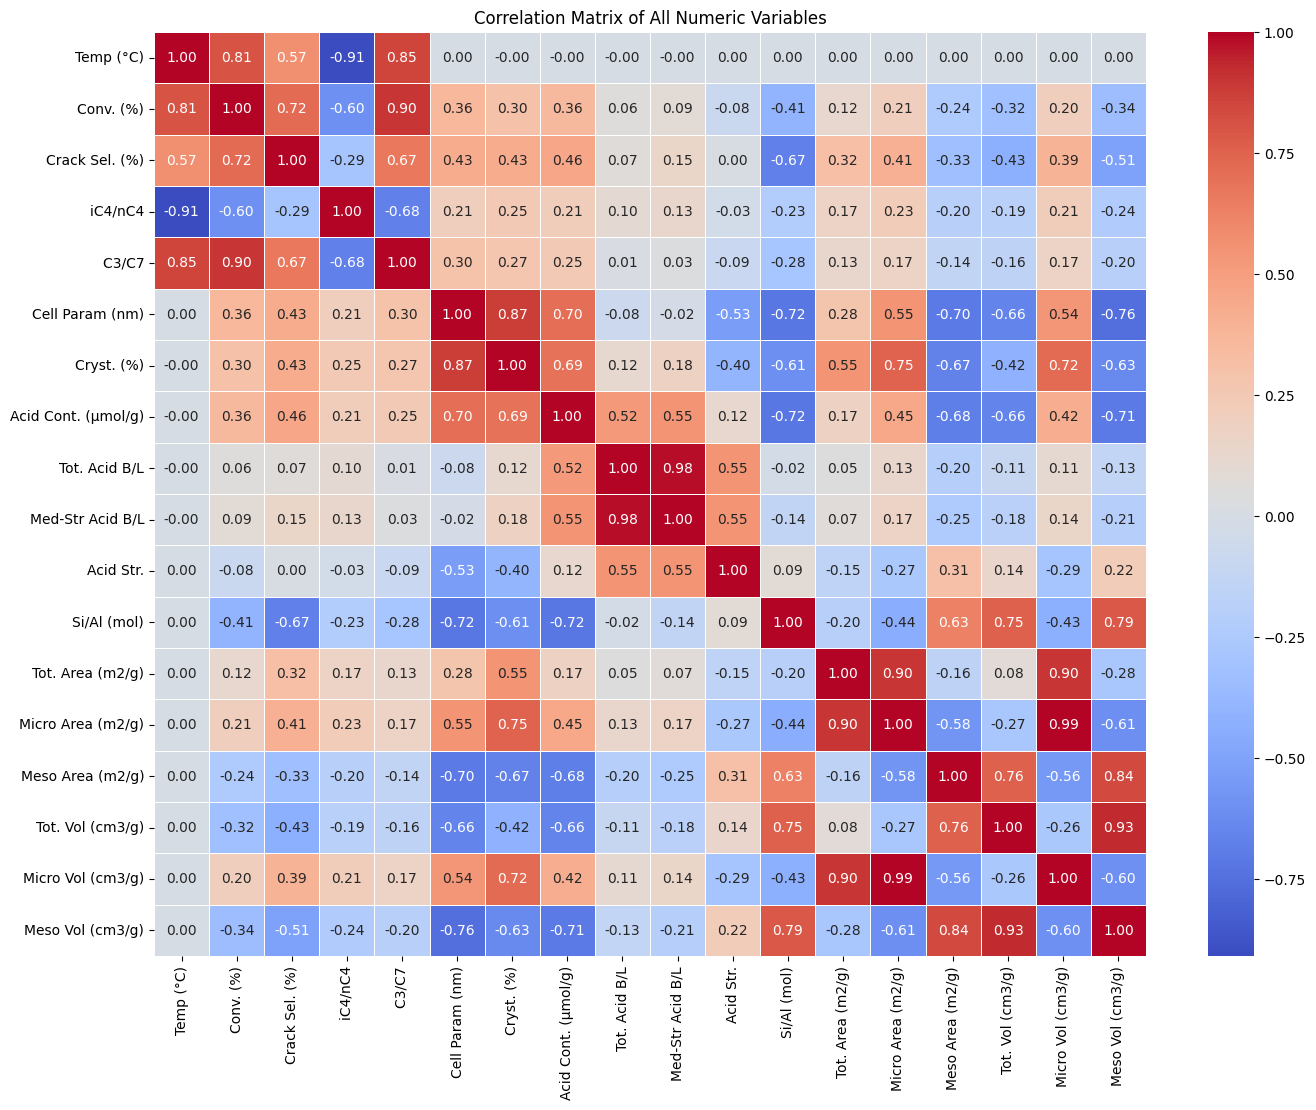

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numeric Variables')
plt.show()

Pairs of input variables with |correlation| > 0.8:
- Cell Param (nm) vs Cryst. (%)
- Tot. Acid B/L vs Med-Str Acid B/L
- Tot. Area (m2/g) vs Micro Area (m2/g)
- Tot. Area (m2/g) vs Micro Vol (cm3/g)
- Micro Area (m2/g) vs Micro Vol (cm3/g)
- Tot. Vol (cm3/g) vs Meso Vol (cm3/g)


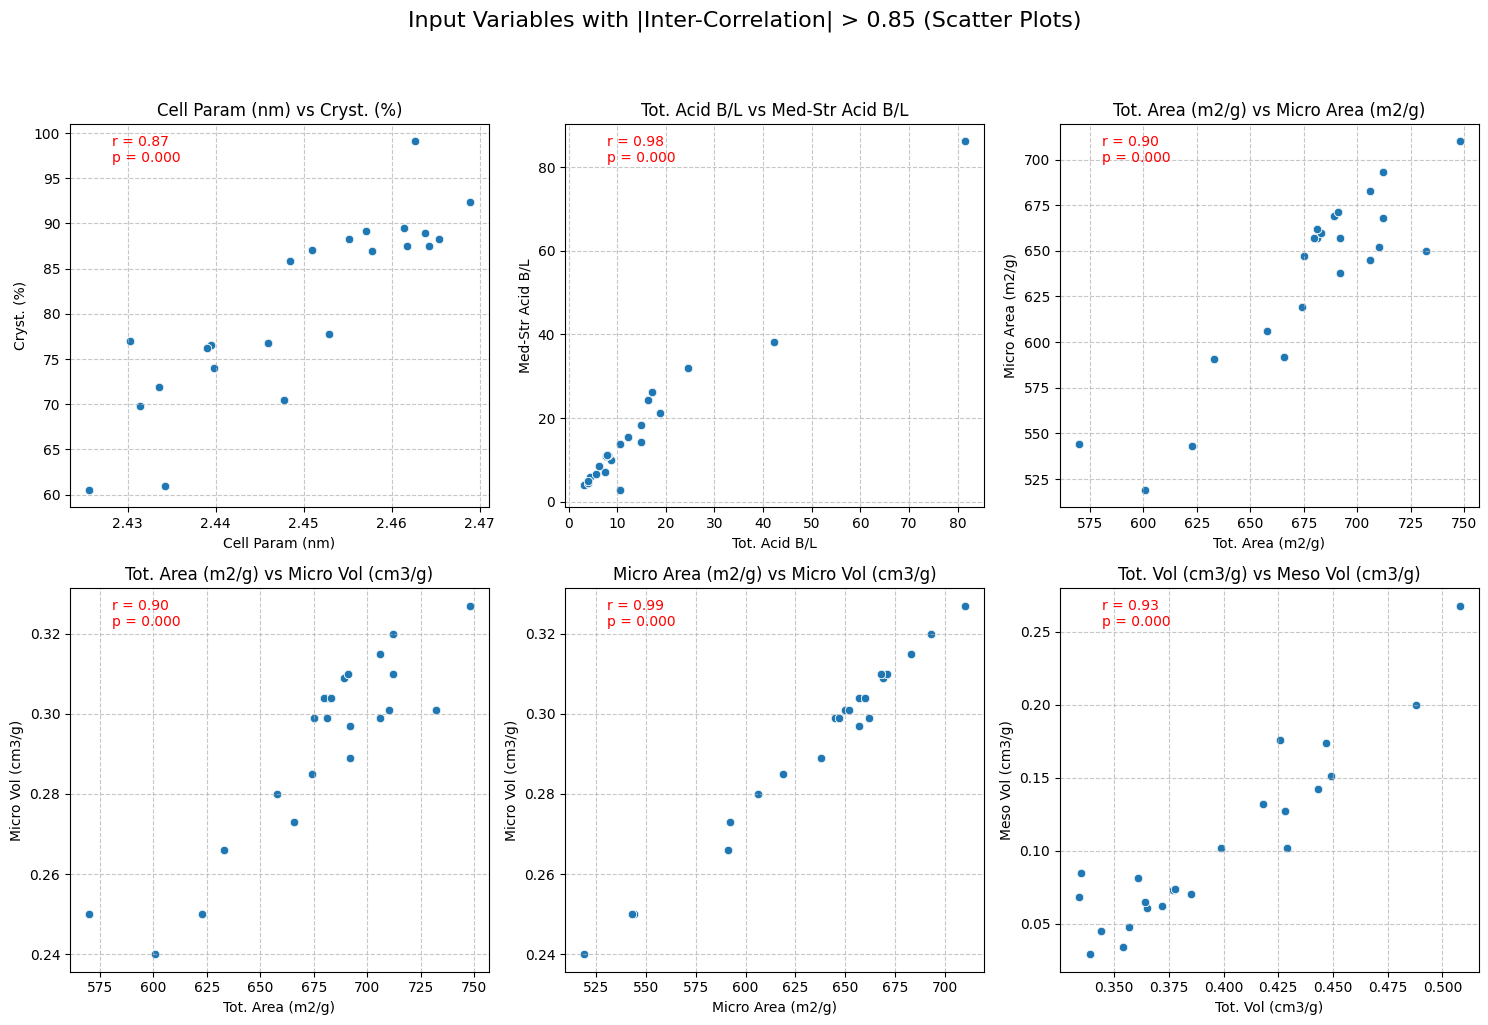

In [ ]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

def annotate_corr_pvalue(x, y, ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    r, p = stats.pearsonr(x, y)
    # Plot scatter points first
    sns.scatterplot(x=x, y=y, ax=ax, **kwargs)
    # Then annotate with correlation and p-value
    ax.annotate(f'r = {r:.2f}\np = {p:.3f}', xy=(.1, .9),
                xycoords=ax.transAxes, fontsize=10, color='red')

# Calculate the correlation matrix for only the condition columns
condition_correlation_matrix = df[condition_cols].corr()

# Get unique pairs of highly inter-correlated input variables
high_corr_pairs = []
for i in range(len(condition_cols)):
    for j in range(i + 1, len(condition_cols)): # Start from i+1 to avoid duplicates and self-correlation
        var1 = condition_cols[i]
        var2 = condition_cols[j]
        correlation_value = condition_correlation_matrix.loc[var1, var2]

        if abs(correlation_value) > 0.85:
            high_corr_pairs.append((var1, var2))

print(f"Pairs of input variables with |correlation| > 0.8:")
for pair in high_corr_pairs:
    print(f"- {pair[0]} vs {pair[1]}")

if not high_corr_pairs:
    print("No pairs of input variables found with |correlation| > 0.85.")
else:
    # Determine grid size for subplots
    num_plots = len(high_corr_pairs)
    cols = 3  # You can adjust the number of columns as needed
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    fig.suptitle('Input Variables with |Inter-Correlation| > 0.85 (Scatter Plots)', y=1.02, fontsize=16)

    for idx, (var1, var2) in enumerate(high_corr_pairs):
        ax = axes[idx]
        annotate_corr_pvalue(df[var1], df[var2], ax=ax)
        ax.set_title(f'{var1} vs {var2}')
        ax.set_xlabel(var1)
        ax.set_ylabel(var2)
        ax.grid(True, linestyle='--', alpha=0.7)

    # Hide any unused subplots
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

Generating pairplot for target columns...


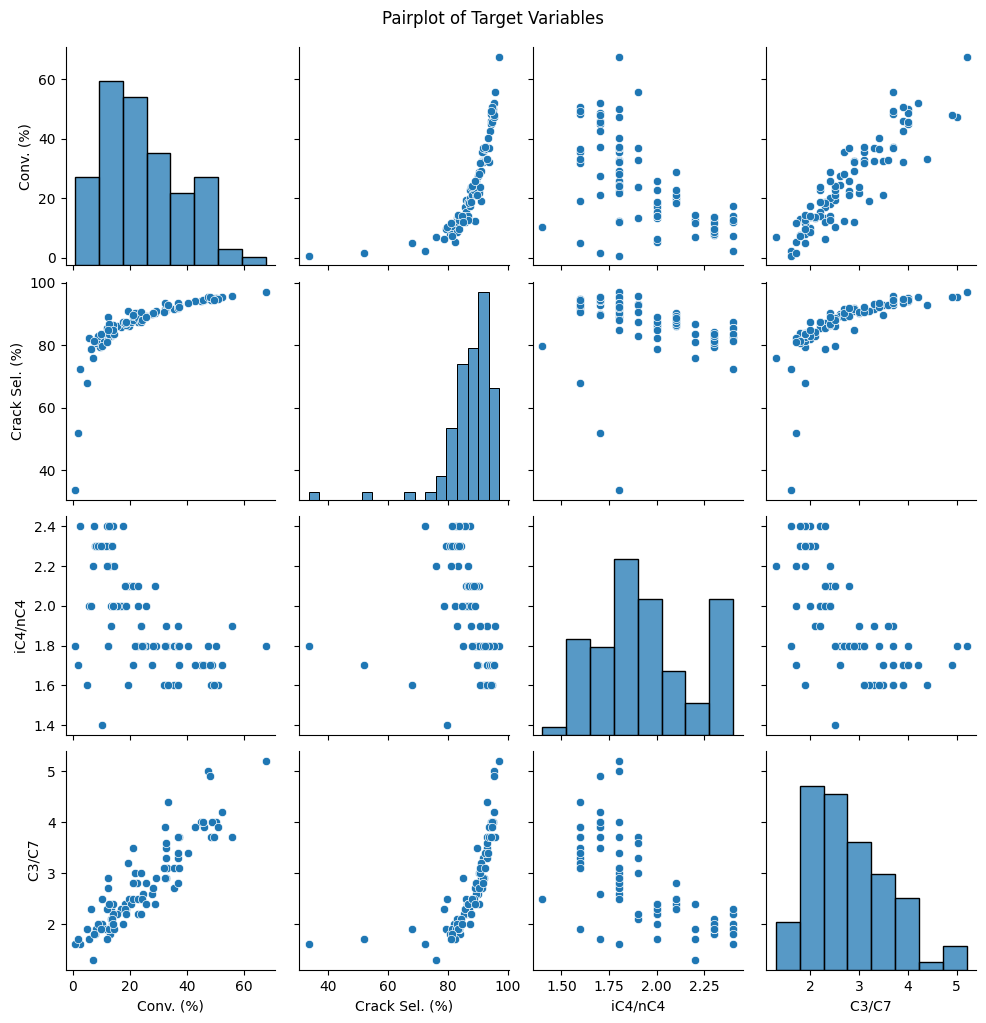

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Multipanel matrixplot for target variables
print("Generating pairplot for target columns...")
sns.pairplot(df[target_cols])
plt.suptitle('Pairplot of Target Variables', y=1.02) # Adjust suptitle position
plt.show()

Plot saved: scatter_Conv._(pct)v_s_Temp_degC_by_ZeoliteID.png


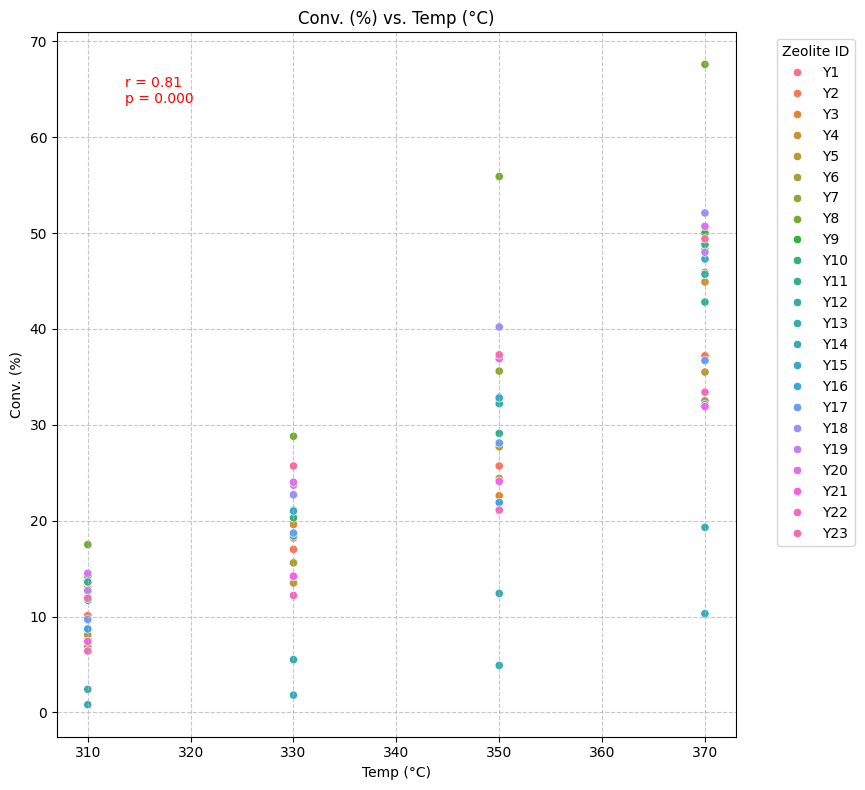

In [ ]:
# Define the target and condition variables
conversion_col = 'Conv. (%)'
temp_col = 'Temp (°C)'

plt.figure(figsize=(10, 8))
# Use the annotate_corr_pvalue function directly, adding hue for Zeolite ID
annotate_corr_pvalue(df[temp_col], df[conversion_col], hue=df[id_col]) # Pass df[id_col] as a Series

plt.title(f'{conversion_col} vs. {temp_col}')
plt.xlabel(temp_col)
plt.ylabel(conversion_col)
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend outside the plot area
plt.legend(title=id_col, bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent elements from being cut off
plt.tight_layout(rect=[0, 0, 0.88, 1])

# Save the figure with an updated filename
clean_temp_col_name = temp_col.replace(' ', '_').replace('°', 'deg').replace('(', '').replace(')', '')
filename = f'scatter_{conversion_col.replace(" ", "_").replace("%", "pct")}v_s_{clean_temp_col_name}_by_ZeoliteID.png'
plt.savefig(filename, bbox_inches='tight')
print(f"Plot saved: {filename}")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split conditions (X) and performance targets (y)
X = df[condition_cols]
y = df['iC4\u200b/nC4\u200b']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
print(f"Random Forest successfully trained on {len(X_train)} samples.")

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation on Test Set:")
#for i, target_col in enumerate(target_cols):
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

    #print(f"--- Metrics for {target_col} ---")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  R-squared (R2): {r2:.4f}")

Random Forest successfully trained on 73 samples.

Model Evaluation on Test Set:
  Mean Absolute Error (MAE): 0.0562
  Mean Squared Error (MSE): 0.0053
  Root Mean Squared Error (RMSE): 0.0729
  R-squared (R2): 0.9395


In [ ]:
import xgboost as xgb

# Initialize the base XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print(f"XGBoost model successfully trained on {len(X_train)} samples.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation on Test Set (XGBoost):")
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"  Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"  Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"  R-squared (R2): {r2_xgb:.4f}")

XGBoost model successfully trained on 73 samples.

Model Evaluation on Test Set (XGBoost):
  Mean Absolute Error (MAE): 0.0632
  Mean Squared Error (MSE): 0.0057
  Root Mean Squared Error (RMSE): 0.0754
  R-squared (R2): 0.9352


## Model Comparison: Random Forest vs. XGBoost (for iC4/nC4)

Now, let's compare the performance metrics of the Random Forest and XGBoost models for predicting `iC4/nC4`.

In [ ]:
import pandas as pd

# --- Random Forest Training Metrics ---
y_train_pred = rf_model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# --- XGBoost Training Metrics ---
y_train_pred_xgb = xgb_model.predict(X_train)
mae_xgb_train = mean_absolute_error(y_train, y_train_pred_xgb)
mse_xgb_train = mean_squared_error(y_train, y_train_pred_xgb)
r2_xgb_train = r2_score(y_train, y_train_pred_xgb)

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Random Forest', 'XGBoost'],
    'R2 (Train)': [r2_train, r2_xgb_train],
    'MAE (Train)': [mae_train, mae_xgb_train],
    'MSE (Train)': [mse_train, mse_xgb_train],
    'R2 (Test)': [r2, r2_xgb],
    'MAE (Test)': [mae, mae_xgb],
    'MSE (Test)': [mse, mse_xgb]
}
comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Performance Comparison (iC4/nC4) ---")
display(comparison_df.round(4))

print("\n--- Conclusion ---")
if r2_xgb > r2:
    print("XGBoost performed slightly better than Random Forest on the test set in terms of R-squared.")
elif r2_xgb < r2:
    print("Random Forest performed slightly better than XGBoost on the test set in terms of R-squared.")
else:
    print("Both models performed similarly on the test set in terms of R-squared.")

# Further analysis of train vs test to check for overfitting
if (r2_train - r2) > 0.1 or (r2_xgb_train - r2_xgb) > 0.1: # Threshold for potential overfitting
    print("Both models show a noticeable drop in R-squared from train to test, indicating some overfitting. \nConsider hyperparameter tuning or regularization for better generalization.")
elif (r2_train - r2) < (r2_xgb_train - r2_xgb):
    print("Random Forest shows slightly better generalization from train to test (less drop in R2).")
else:
    print("XGBoost shows slightly better generalization from train to test (less drop in R2).")


--- Model Performance Comparison (iC4/nC4) ---


,Model,R2 (Train),MAE (Train),MSE (Train),R2 (Test),MAE (Test),MSE (Test)
0,Random Forest,0.9723,0.0291,0.0017,0.9395,0.0562,0.0053
1,XGBoost,0.9999,0.0013,0.0000,0.9352,0.0632,0.0057



--- Conclusion ---
Random Forest performed slightly better than XGBoost on the test set in terms of R-squared.
Random Forest shows slightly better generalization from train to test (less drop in R2).


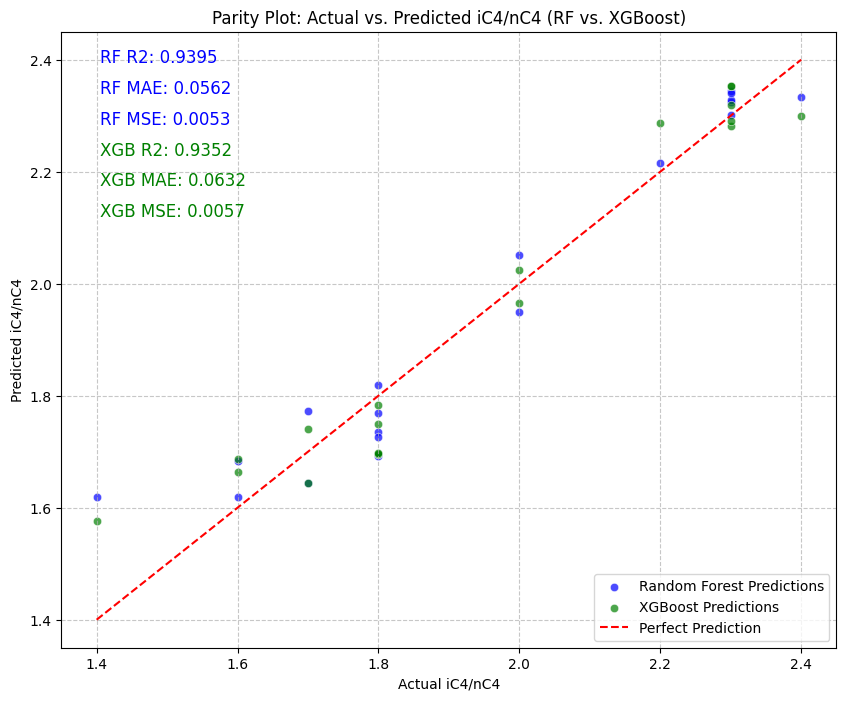

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, label='Random Forest Predictions', color='blue')
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.7, label='XGBoost Predictions', color='green')

# Add a perfect prediction line (y=x)
min_val = min(y_test.min(), y_pred.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Parity Plot: Actual vs. Predicted iC4/nC4 (RF vs. XGBoost)')
plt.xlabel('Actual iC4/nC4')
plt.ylabel('Predicted iC4/nC4')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotate with RF metrics
plt.annotate(f'RF R2: {r2:.4f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, color='blue')
plt.annotate(f'RF MAE: {mae:.4f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=12, color='blue')
plt.annotate(f'RF MSE: {mse:.4f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12, color='blue')

# Annotate with XGBoost metrics
plt.annotate(f'XGB R2: {r2_xgb:.4f}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=12, color='green')
plt.annotate(f'XGB MAE: {mae_xgb:.4f}', xy=(0.05, 0.75), xycoords='axes fraction', fontsize=12, color='green')
plt.annotate(f'XGB MSE: {mse_xgb:.4f}', xy=(0.05, 0.70), xycoords='axes fraction', fontsize=12, color='green')

plt.show()

## Cross-validation for Random Forest Robustness

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Re-initialize the Random Forest model with the same parameters
rf_model_cv = RandomForestRegressor(n_estimators=300, random_state=42)

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get R-squared scores for each fold
cv_scores = cross_val_score(rf_model_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')

print(f"Cross-validation mse scores: {-cv_scores}")
print(f"Mean cross-validation mse: {-cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation mse: {cv_scores.std():.4f}")

# You can also perform cross-validation for XGBoost to compare robustness
xgb_model_cv = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

cv_scores_xgb = cross_val_score(xgb_model_cv, X, y, cv=kf, scoring='neg_mean_absolute_error')

print(f"\nCross-validation mse scores (XGBoost): {-cv_scores_xgb}")
print(f"Mean cross-validation mse (XGBoost): {-cv_scores_xgb.mean():.4f}")
print(f"Standard deviation of cross-validation mse (XGBoost): {cv_scores_xgb.std():.4f}")

Cross-validation mse scores: [0.05661404 0.05261404 0.08003704 0.07866667 0.08305556]
Mean cross-validation mse: 0.0702
Standard deviation of cross-validation mse: 0.0129

Cross-validation mse scores (XGBoost): [0.06316404 0.05880524 0.09490623 0.07777216 0.08424755]
Mean cross-validation mse (XGBoost): 0.0758
Standard deviation of cross-validation mse (XGBoost): 0.0133


## Feature Importance from Random Forest

Feature Importances (Random Forest):
                Feature  Importance
0             Temp (°C)    0.820752
2            Cryst. (%)    0.025226
9     Micro Area (m2/g)    0.020547
13     Meso Vol (cm3/g)    0.018600
10     Meso Area (m2/g)    0.018413
3   Acid Cont. (μmol/g)    0.014853
1       Cell Param (nm)    0.012023
8      Tot. Area (m2/g)    0.011833
11     Tot. Vol (cm3/g)    0.011761
7           Si/Al (mol)    0.010927
4         Tot. Acid B/L    0.010372
5      Med-Str Acid B/L    0.009504
12    Micro Vol (cm3/g)    0.008254
6             Acid Str.    0.006935


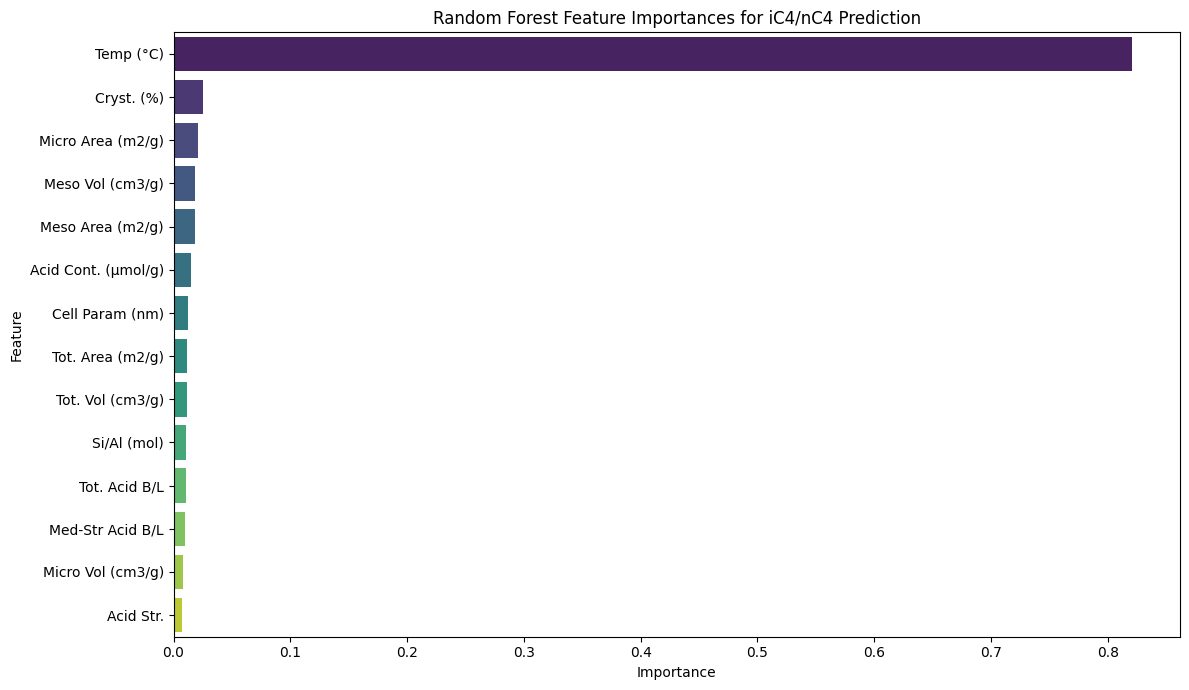

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Random Forest):")
print(features_df)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importances for iC4/nC4 Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Synthetic data generation using GAN

In [ ]:
# Synthetic data generation using GAN
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Initializing Data for Synthetic Profile Generation ---")
# Data preparation
id_col = 'Zeolite ID'
df.columns = df.columns.str.strip().str.replace('*', '')
features = [c for c in df.columns if c != id_col]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df [features])
tensor_data = torch.FloatTensor(scaled_data)


--- Initializing Data for Synthetic Profile Generation ---


Training Standard GAN to learn full zeolite features...
Training complete.
Generating 50 entirely new synthetic zeolites...
Saved synthetic zeolites to 'Synthetic_Zeolite_Profiles.csv'.
Saved analysis plots to 'synthetic_zeolite_analysis.png'.


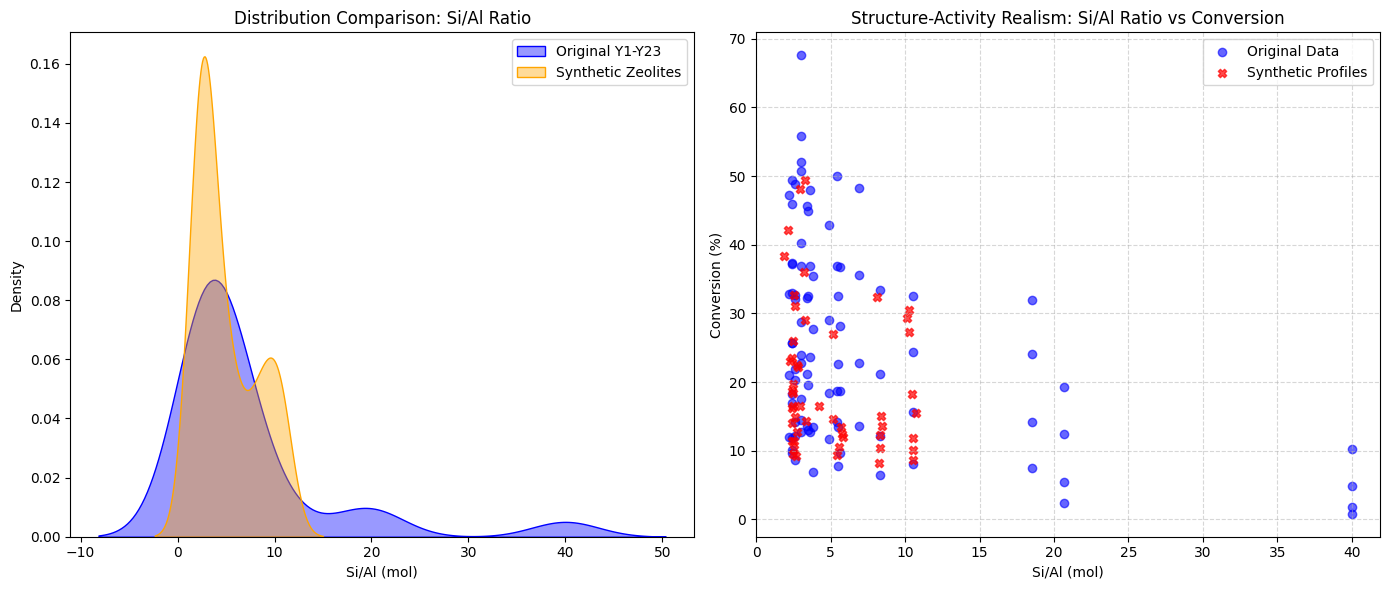

In [ ]:
# Define Standard GAN Architecture
feature_dim = len(features)
noise_dim = 12
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, feature_dim)
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Train the GAN
G = Generator()
D = Discriminator()
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

epochs = 3000
batch_size = 16

print("Training Standard GAN to learn full zeolite features...")
for epoch in range(epochs):
    indices = torch.randperm(len(tensor_data))
    shuffled_data = tensor_data[indices]

    for i in range(0, len(tensor_data), batch_size):
        real_batch = shuffled_data[i:i+batch_size]
        b_size = len(real_batch)

        # Train Discriminator
        opt_D.zero_grad()
        real_labels = torch.ones(b_size, 1)
        fake_labels = torch.zeros(b_size, 1)

        out_real = D(real_batch)
        loss_D_real = criterion(out_real, real_labels)

        z = torch.randn(b_size, noise_dim)
        fake_batch = G(z)
        out_fake = D(fake_batch.detach())
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator
        opt_G.zero_grad()
        z = torch.randn(b_size, noise_dim)
        fake_batch = G(z)
        out_fake = D(fake_batch)
        loss_G = criterion(out_fake, real_labels)
        loss_G.backward()
        opt_G.step()

print("Training complete.")

# Generate New Synthetic Data
print("Generating 50 entirely new synthetic zeolites...")
num_synthetic = 50
G.eval()
with torch.no_grad():
    z_synthetic = torch.randn(num_synthetic, noise_dim)
    synthetic_scaled = G(z_synthetic)
    synthetic_data = scaler.inverse_transform(synthetic_scaled.numpy())

df_synthetic = pd.DataFrame(synthetic_data, columns=features)

# Apply basic physical constraints (no negative areas, lengths, or percentages)
for col in features:
    # Everything in this dataset should be non-negative
    df_synthetic[col] = df_synthetic[col].clip(lower=0)

# Cap percentages at 100%
pct_cols = [c for c in features if '%' in c or 'Sel' in c or 'Conv' in c]
for col in pct_cols:
    df_synthetic[col] = df_synthetic[col].clip(upper=100)

df_synthetic.insert(0, id_col, [f'Syn-Y{i+1}' for i in range(num_synthetic)])

df_synthetic.to_csv('Synthetic_Zeolite_Profiles.csv', index=False)
print("Saved synthetic zeolites to 'Synthetic_Zeolite_Profiles.csv'.")

# Plotting to evaluate synthetic data
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of Si/Al Ratio
plt.subplot(1, 2, 1)
sns.kdeplot(df['Si/Al (mol)'], label='Original Y1-Y23', fill=True, color='blue', alpha=0.4)
sns.kdeplot(df_synthetic['Si/Al (mol)'], label='Synthetic Zeolites', fill=True, color='orange', alpha=0.4)
plt.title('Distribution Comparison: Si/Al Ratio')
plt.xlabel('Si/Al (mol)')
plt.ylabel('Density')
plt.legend()

# Subplot 2: Chemical Rule verification (Si/Al vs Conversion)
# Note: Lower Si/Al generally correlates with higher conversion in this dataset at identical temps
plt.subplot(1, 2, 2)
plt.scatter(df['Si/Al (mol)'], df['Conv. (%)'], alpha=0.6, label='Original Data', color='blue')
plt.scatter(df_synthetic['Si/Al (mol)'], df_synthetic['Conv. (%)'], alpha=0.7, marker='X', label='Synthetic Profiles', color='red')
plt.title('Structure-Activity Realism: Si/Al Ratio vs Conversion')
plt.xlabel('Si/Al (mol)')
plt.ylabel('Conversion (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('synthetic_zeolite_analysis.png', bbox_inches='tight')
print("Saved analysis plots to 'synthetic_zeolite_analysis.png'.")



### Comparison of Original and Synthetic Data for iC4/nC4 Ratio

Saved analysis plots to 'synthetic_zeolite_ic4_nc4_analysis.png'.


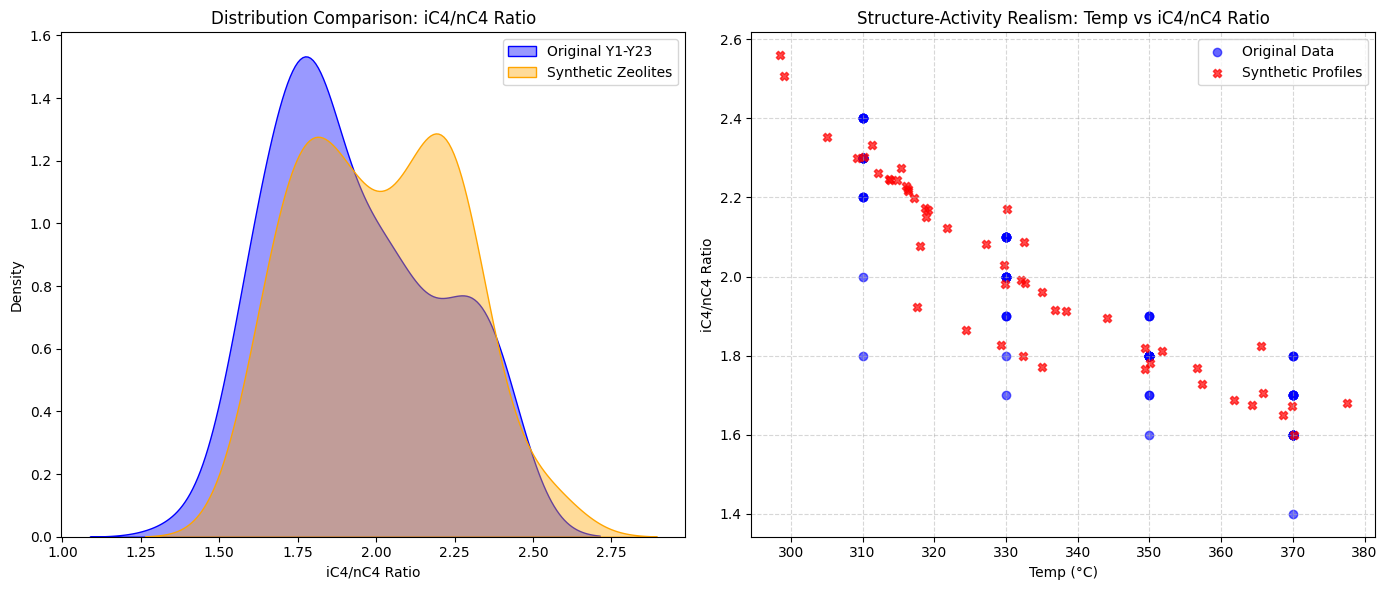

In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of iC4/nC4 Ratio
plt.subplot(1, 2, 1)
sns.kdeplot(df['iC4\u200b/nC4\u200b'], label='Original Y1-Y23', fill=True, color='blue', alpha=0.4)
sns.kdeplot(df_synthetic['iC4\u200b/nC4\u200b'], label='Synthetic Zeolites', fill=True, color='orange', alpha=0.4)
plt.title('Distribution Comparison: iC4/nC4 Ratio')
plt.xlabel('iC4/nC4 Ratio')
plt.ylabel('Density')
plt.legend()

# Subplot 2: Chemical Rule verification (iC4/nC4 vs Temperature)
plt.subplot(1, 2, 2)
plt.scatter(df['Temp (°C)'], df['iC4\u200b/nC4\u200b'], alpha=0.6, label='Original Data', color='blue')
plt.scatter(df_synthetic['Temp (°C)'], df_synthetic['iC4\u200b/nC4\u200b'], alpha=0.7, marker='X', label='Synthetic Profiles', color='red')
plt.title('Structure-Activity Realism: Temp vs iC4/nC4 Ratio')
plt.xlabel('Temp (°C)')
plt.ylabel('iC4/nC4 Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('synthetic_zeolite_ic4_nc4_analysis.png', bbox_inches='tight')
print("Saved analysis plots to 'synthetic_zeolite_ic4_nc4_analysis.png'.")
plt.show()

### Comparación de Datos Originales y Sintéticos para la Distribución de 'Conv. (%)'

Saved analysis plots to 'synthetic_zeolite_conv_analysis.png'.


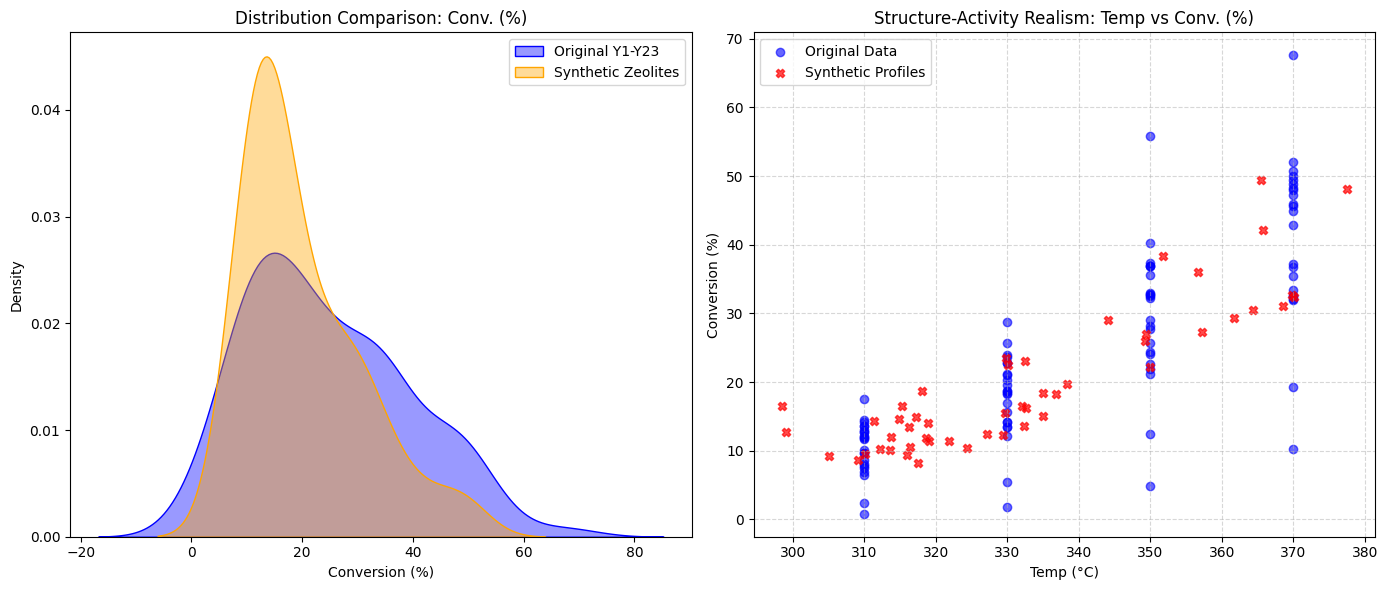

In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of Conversion (%)
plt.subplot(1, 2, 1)
sns.kdeplot(df['Conv. (%)'], label='Original Y1-Y23', fill=True, color='blue', alpha=0.4)
sns.kdeplot(df_synthetic['Conv. (%)'], label='Synthetic Zeolites', fill=True, color='orange', alpha=0.4)
plt.title('Distribution Comparison: Conv. (%)')
plt.xlabel('Conversion (%)')
plt.ylabel('Density')
plt.legend()

# Subplot 2: Chemical Rule verification (Conversion (%) vs Temperature)
plt.subplot(1, 2, 2)
plt.scatter(df['Temp (°C)'], df['Conv. (%)'], alpha=0.6, label='Original Data', color='blue')
plt.scatter(df_synthetic['Temp (°C)'], df_synthetic['Conv. (%)'], alpha=0.7, marker='X', label='Synthetic Profiles', color='red')
plt.title('Temp vs Conv. (%)')
plt.xlabel('Temp (°C)')
plt.ylabel('Conversion (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('synthetic_zeolite_conv_analysis.png', bbox_inches='tight')
print("Saved analysis plots to 'synthetic_zeolite_conv_analysis.png'.")
plt.show()

### Validating Synthetic Data with RF model


Model Evaluation on Synthetic Data (Random Forest):
  Mean Absolute Error (MAE): 0.0697
  Mean Squared Error (MSE): 0.0081
  R-squared (R2): 0.8606
Saved parity plot for synthetic data to 'rf_synthetic_data_parity_plot.png'.


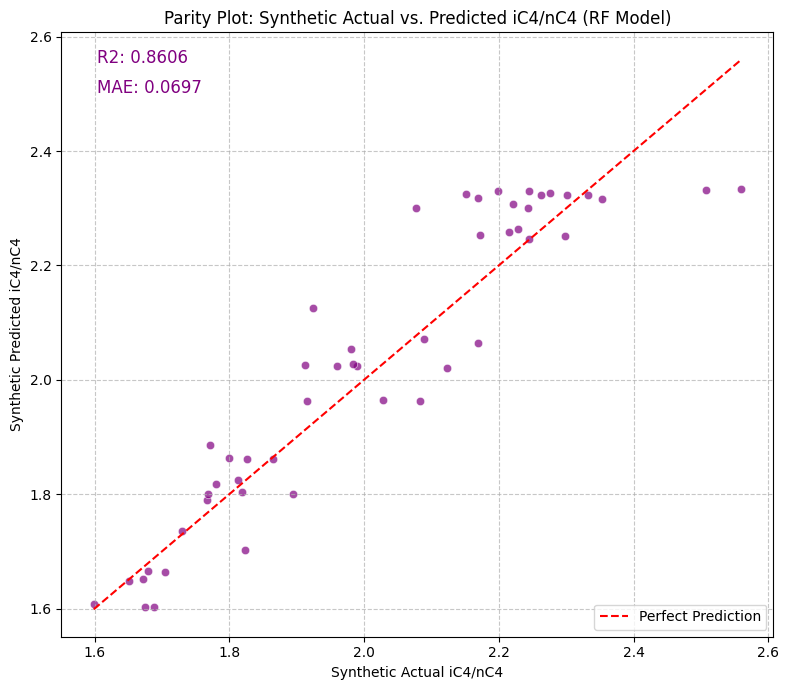

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare synthetic data for prediction
X_synthetic = df_synthetic[condition_cols]
y_synthetic_actual = df_synthetic['iC4\u200b/nC4\u200b']

# Predict using the trained Random Forest model
y_synthetic_pred_rf = rf_model.predict(X_synthetic)

# Calculate metrics for synthetic data
mae_synthetic_rf = mean_absolute_error(y_synthetic_actual, y_synthetic_pred_rf)
mse_synthetic_rf = mean_squared_error(y_synthetic_actual, y_synthetic_pred_rf)
r2_synthetic_rf = r2_score(y_synthetic_actual, y_synthetic_pred_rf)

print("\nModel Evaluation on Synthetic Data (Random Forest):")
print(f"  Mean Absolute Error (MAE): {mae_synthetic_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_synthetic_rf:.4f}")
print(f"  R-squared (R2): {r2_synthetic_rf:.4f}")

# Parity plot for synthetic data
plt.figure(figsize=(8, 7))
sns.scatterplot(x=y_synthetic_actual, y=y_synthetic_pred_rf, alpha=0.7, color='purple')

# Add a perfect prediction line (y=x)
min_val = min(y_synthetic_actual.min(), y_synthetic_pred_rf.min())
max_val = max(y_synthetic_actual.max(), y_synthetic_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Parity Plot: Synthetic Actual vs. Predicted iC4/nC4 (RF Model)')
plt.xlabel('Synthetic Actual iC4/nC4')
plt.ylabel('Synthetic Predicted iC4/nC4')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotate with metrics
plt.annotate(f'R2: {r2_synthetic_rf:.4f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, color='purple')
plt.annotate(f'MAE: {mae_synthetic_rf:.4f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=12, color='purple')

plt.tight_layout()
plt.savefig('rf_synthetic_data_parity_plot.png', bbox_inches='tight')
print("Saved parity plot for synthetic data to 'rf_synthetic_data_parity_plot.png'.")
plt.show()

### Análisis de la Zeolita Sintética con Mayor iC4/nC4 Ratio

In [ ]:
# Identify the synthetic zeolite with the highest iC4/nC4 ratio
highest_ic4_syn_zeolite = df_synthetic.loc[df_synthetic['iC4\u200b/nC4\u200b'].idxmax()]

print("Synthetic Zeolite with Highest iC4/nC4 Ratio:")
display(highest_ic4_syn_zeolite)

print("\nDescriptive Statistics for Original Zeolites (Condition Variables):")
display(df[condition_cols].describe())

Synthetic Zeolite with Highest iC4/nC4 Ratio:


,4
Zeolite ID,Syn-Y5
Temp (°C),298.467255
Conv. (%),16.447832
Crack Sel. (%),84.608727
iC4​/nC4​,2.559458
C3​/C7​,1.819762
Cell Param (nm),2.462411
Cryst. (%),87.714638
Acid Cont. (μmol/g),1482.349487
Tot. Acid B/L,8.124055



Descriptive Statistics for Original Zeolites (Condition Variables):


,Temp (°C),Cell Param (nm),Cryst. (%),Acid Cont. (μmol/g),Tot. Acid B/L,Med-Str Acid B/L,Acid Str.,Si/Al (mol),Tot. Area (m2/g),Micro Area (m2/g),Meso Area (m2/g),Tot. Vol (cm3/g),Micro Vol (cm3/g),Meso Vol (cm3/g)
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.00000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,340.000000,2.449474,80.986957,1242.408696,14.600000,16.665217,335.595652,7.13913,678.913043,636.217391,42.652174,0.395652,0.292696,0.103000
std,22.483205,0.012865,9.880219,524.593359,16.688747,17.563789,47.990241,8.52630,40.132652,48.473812,21.603029,0.048505,0.022679,0.058789
min,310.000000,2.425600,60.500000,117.800000,3.200000,2.800000,257.300000,2.20000,570.000000,519.000000,19.000000,0.334000,0.240000,0.029000
25%,325.000000,2.439000,74.000000,909.100000,5.600000,5.800000,272.900000,2.60000,666.000000,606.000000,23.000000,0.357000,0.280000,0.062000
50%,340.000000,2.451000,85.800000,1353.300000,8.800000,11.200000,352.400000,3.60000,683.000000,652.000000,38.000000,0.378000,0.299000,0.081000
75%,355.000000,2.461700,88.300000,1523.000000,16.400000,21.300000,369.900000,6.90000,706.000000,668.000000,58.000000,0.429000,0.309000,0.142000
max,370.000000,2.468900,99.100000,2261.400000,81.500000,86.200000,411.500000,40.00000,748.000000,710.000000,83.000000,0.508000,0.327000,0.268000
